# IF3170 Artificial Intelligence | Tugas Besar 2

This notebook serves as a template for the assignment. Please create a copy of this notebook to complete your work. You can add more code blocks, markdown blocks, or new sections if needed.


Group Number: 06

Group Members:
- Richard Christian 13523024
- Kenneth Poenadi Name 13523040
- Ivan Wirawan 13523046
- Bob Kunanda 13523086
- M Zahran Ramadhan 13523104

## Import Libraries

In [1]:
# ==================== IMPORTS ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn imports
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.preprocessing import PowerTransformer, QuantileTransformer, Normalizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.base import BaseEstimator, TransformerMixin

# Imbalanced data handling
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Model interpretation
import shap

# Deep learning for autoencoders
try:
    from tensorflow import keras
    from tensorflow.keras import layers
    KERAS_AVAILABLE = True
except:
    KERAS_AVAILABLE = False
    print("Warning: TensorFlow not available. Autoencoder will be disabled.")

# Model persistence
import joblib
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 67

## Import Dataset

In [ ]:

df = pd.read_csv("../data/train.csv")
df_test = pd.read_csv("../data/test.csv")

# Exploratory Data Analysis (Optional)

Exploratory Data Analysis (EDA) is a crucial step in the data analysis process that involves examining and visualizing data sets to uncover patterns, trends, anomalies, and insights. It is the first step before applying more advanced statistical and machine learning techniques. EDA helps you to gain a deep understanding of the data you are working with, allowing you to make informed decisions and formulate hypotheses for further analysis.

In [ ]:
# profile = ProfileReport(df, title="EDA Report", explorative=True)
# profile.to_notebook_iframe()


In [4]:
categorical_cols = [
    'Marital status', 'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance\t', 'Previous qualification',  'Gender', 'Nacionality', 
    'Mother\'s qualification', 'Father\'s qualification', 'Mother\'s occupation', 'Father\'s occupation',
    'Educational special needs', 'International',
    'Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Displaced'
]

df[categorical_cols] = df[categorical_cols].astype(str)
df_test[categorical_cols] = df_test[categorical_cols].astype(str)
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3096 entries, 0 to 3095
Data columns (total 38 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Student_ID                                      3096 non-null   int64  
 1   Marital status                                  3096 non-null   object 
 2   Application mode                                3096 non-null   object 
 3   Application order                               3096 non-null   object 
 4   Course                                          3096 non-null   object 
 5   Daytime/evening attendance	                     3096 non-null   object 
 6   Previous qualification                          3096 non-null   object 
 7   Previous qualification (grade)                  3096 non-null   float64
 8   Nacionality                                     3096 non-null   object 
 9   Mother's qualification                   

In [5]:
def top3_categories_per_target(df, target_col="Target"):
    """
    Melihat 3 kategori teratas untuk setiap kelas target dalam setiap kolom kategorikal.
    """
    df = df.copy()

    categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

    if target_col in categorical_cols:
        categorical_cols.remove(target_col)

    print("===== TOP 3 CATEGORIES FOR EACH TARGET CLASS =====\n")

    for col in categorical_cols:
        print(f"\n--- Column: {col} ---")

        grouped = df.groupby([target_col, col]).size().reset_index(name="count")

        for target_value in df[target_col].unique():
            subset = grouped[grouped[target_col] == target_value].sort_values("count", ascending=False).head(3)

            print(f"\nTarget = {target_value}:")
            if subset.empty:
                print("  (No data)")
            else:
                for _, row in subset.iterrows():
                    print(f"  {row[col]} → {row['count']} times")

top3_categories_per_target(df)

===== TOP 3 CATEGORIES FOR EACH TARGET CLASS =====


--- Column: Marital status ---

Target = Graduate:
  1 → 1415 times
  2 → 102 times
  4 → 23 times

Target = Dropout:
  1 → 830 times
  2 → 127 times
  4 → 29 times

Target = Enrolled:
  1 → 513 times
  2 → 30 times
  4 → 10 times

--- Column: Application mode ---

Target = Graduate:
  1 → 765 times
  17 → 310 times
  39 → 151 times

Target = Dropout:
  39 → 308 times
  1 → 238 times
  17 → 184 times

Target = Enrolled:
  1 → 215 times
  17 → 115 times
  39 → 79 times

--- Column: Application order ---

Target = Graduate:
  1 → 979 times
  2 → 212 times
  3 → 123 times

Target = Dropout:
  1 → 738 times
  2 → 109 times
  3 → 52 times

Target = Enrolled:
  1 → 398 times
  2 → 67 times
  3 → 47 times

--- Column: Course ---

Target = Graduate:
  9500 → 373 times
  9238 → 181 times
  9773 → 134 times

Target = Dropout:
  9991 → 101 times
  9147 → 93 times
  9500 → 77 times

Target = Enrolled:
  9147 → 80 times
  9500 → 73 times
  9085 →

# 2. Data Cleaning and Preprocessing

This step is the first thing to be done once a Data Scientist have grasped a general knowledge of the data. Raw data is **seldom ready for training**, therefore steps need to be taken to clean and format the data for the Machine Learning model to interpret.

By performing data cleaning and preprocessing, you ensure that your dataset is ready for model training, leading to more accurate and reliable machine learning results. These steps are essential for transforming raw data into a format that machine learning algorithms can effectively learn from and make predictions.

We will give some common methods for you to try, but you only have to **at least implement one method for each process**. For each step that you will do, **please explain the reason why did you do that process. Write it in a markdown cell under the code cell you wrote.**

## A. Data Cleaning

**Data cleaning** is the crucial first step in preparing your dataset for machine learning. Raw data collected from various sources is often messy and may contain errors, missing values, and inconsistencies. Data cleaning involves the following steps:

1. **Handling Missing Data:** Identify and address missing values in the dataset. This can include imputing missing values, removing rows or columns with excessive missing data, or using more advanced techniques like interpolation.

2. **Dealing with Outliers:** Identify and handle outliers, which are data points significantly different from the rest of the dataset. Outliers can be removed or transformed to improve model performance.

3. **Data Validation:** Check for data integrity and consistency. Ensure that data types are correct, categorical variables have consistent labels, and numerical values fall within expected ranges.

4. **Removing Duplicates:** Identify and remove duplicate rows, as they can skew the model's training process and evaluation metrics.

5. **Feature Engineering**: Create new features or modify existing ones to extract relevant information. This step can involve scaling, normalizing, or encoding features for better model interpretability.

### I. Handling Missing Data

Missing data can adversely affect the performance and accuracy of machine learning models. There are several strategies to handle missing data in machine learning:

1. **Data Imputation:**

    a. **Mean, Median, or Mode Imputation:** For numerical features, you can replace missing values with the mean, median, or mode of the non-missing values in the same feature. This method is simple and often effective when data is missing at random.

    b. **Constant Value Imputation:** You can replace missing values with a predefined constant value (e.g., 0) if it makes sense for your dataset and problem.

    c. **Imputation Using Predictive Models:** More advanced techniques involve using predictive models to estimate missing values. For example, you can train a regression model to predict missing numerical values or a classification model to predict missing categorical values.

2. **Deletion of Missing Data:**

    a. **Listwise Deletion:** In cases where the amount of missing data is relatively small, you can simply remove rows with missing values from your dataset. However, this approach can lead to a loss of valuable information.

    b. **Column (Feature) Deletion:** If a feature has a large number of missing values and is not critical for your analysis, you can consider removing that feature altogether.

3. **Domain-Specific Strategies:**

    a. **Domain Knowledge:** In some cases, domain knowledge can guide the imputation process. For example, if you know that missing values are related to a specific condition, you can impute them accordingly.

4. **Imputation Libraries:**

    a. **Scikit-Learn:** Scikit-Learn provides a `SimpleImputer` class that can handle basic imputation strategies like mean, median, and mode imputation.

    b. **Fancyimpute:** Fancyimpute is a Python library that offers more advanced imputation techniques, including matrix factorization, k-nearest neighbors, and deep learning-based methods.

The choice of imputation method should be guided by the nature of your data, the amount of missing data, the problem you are trying to solve, and the assumptions you are willing to make.

### III. Remove Duplicates
Handling duplicate values is crucial because they can compromise data integrity, leading to inaccurate analysis and insights. Duplicate entries can bias machine learning models, causing overfitting and reducing their ability to generalize to new data. They also inflate the dataset size unnecessarily, increasing computational costs and processing times. Additionally, duplicates can distort statistical measures and lead to inconsistencies, ultimately affecting the reliability of data-driven decisions and reporting. Ensuring data quality by removing duplicates is essential for accurate, efficient, and consistent analysis.

In [ ]:
df = df.drop_duplicates()
print(f"Rows after duplicate removal: {df.shape[0]}")

Rows after duplicate removal: 3096


### IV. Feature Engineering

**Feature engineering** involves creating new features (input variables) or transforming existing ones to improve the performance of machine learning models. Feature engineering aims to enhance the model's ability to learn patterns and make accurate predictions from the data. It's often said that "good features make good models."

1. **Feature Selection:** Feature engineering can involve selecting the most relevant and informative features from the dataset. Removing irrelevant or redundant features not only simplifies the model but also reduces the risk of overfitting.

2. **Creating New Features:** Sometimes, the existing features may not capture the underlying patterns effectively. In such cases, engineers create new features that provide additional information. For example:
   
   - **Polynomial Features:** Engineers may create new features by taking the square, cube, or other higher-order terms of existing numerical features. This can help capture nonlinear relationships.
   
   - **Interaction Features:** Interaction features are created by combining two or more existing features. For example, if you have features "length" and "width," you can create an "area" feature by multiplying them.

3. **Binning or Discretization:** Continuous numerical features can be divided into bins or categories. For instance, age values can be grouped into bins like "child," "adult," and "senior."

4. **Domain-Specific Feature Engineering:** Depending on the domain and problem, engineers may create domain-specific features. For example, in fraud detection, features related to transaction history and user behavior may be engineered to identify anomalies.

Feature engineering is both a creative and iterative process. It requires a deep understanding of the data, domain knowledge, and experimentation to determine which features will enhance the model's predictive power.

In [ ]:
# ==================== SAFE FEATURE ENGINEERING (HANDLES DIVISION BY ZERO) ====================
import numpy as np
import pandas as pd

def add_features(df):
    """
    Penambahan feature engineering
    """
    df = df.copy()
    
    # Age grouping - simplifikasi
    df["Age_Group"] = pd.cut(
        df["Age at enrollment"],
        bins=[0, 18, 20, 25, 100],
        labels=[1, 2, 3, 4],
        right=True
    ).astype(float)  # Convert to float to avoid categorical dtype issues

    # Semester 1 - Persentase lulus 
    df["S1_Pass_Rate"] = np.where(
        df["Curricular units 1st sem (enrolled)"] > 0,
        df["Curricular units 1st sem (approved)"] / df["Curricular units 1st sem (enrolled)"],
        0.0  
    )

    # Semester 1 - Persentase kehadiran evaluasi
    df["S1_Evaluation_Attendance_Rate"] = np.where(
        df["Curricular units 1st sem (enrolled)"] > 0,
        df["Curricular units 1st sem (evaluations)"] / df["Curricular units 1st sem (enrolled)"],
        0.0
    )

    # Semester 1 - Persentase menghindari evaluasi
    df["S1_Avoidance_Rate"] = 1.0 - df["S1_Evaluation_Attendance_Rate"]

    # Semester 2 - Persentase lulus 
    df["S2_Pass_Rate"] = np.where(
        df["Curricular units 2nd sem (enrolled)"] > 0,
        df["Curricular units 2nd sem (approved)"] / df["Curricular units 2nd sem (enrolled)"],
        0.0
    )

    # Semester 2 - Persentase kehadiran evaluasi
    df["S2_Evaluation_Attendance_Rate"] = np.where(
        df["Curricular units 2nd sem (enrolled)"] > 0,
        df["Curricular units 2nd sem (evaluations)"] / df["Curricular units 2nd sem (enrolled)"],
        0.0
    )

    # Semester 2 - Persentase menghindari evaluasi
    df["S2_Avoidance_Rate"] = 1.0 - df["S2_Evaluation_Attendance_Rate"]

    # Progress Metrics
    df["Pass_rate_progress"] = df["S2_Pass_Rate"] - df["S1_Pass_Rate"]
    df["Grade_progress"] = df["Curricular units 2nd sem (grade)"] - df["Curricular units 1st sem (grade)"]
    df["Attendance_progress"] = df["S2_Evaluation_Attendance_Rate"] - df["S1_Evaluation_Attendance_Rate"]
    df["Avoidance_progress"] = df["S2_Avoidance_Rate"] - df["S1_Avoidance_Rate"]
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], 0)
    df[numeric_cols] = df[numeric_cols].fillna(0)
    
    return df

## B. Data Preprocessing

**Data preprocessing** is a broader step that encompasses both data cleaning and additional transformations to make the data suitable for machine learning algorithms. Its primary goals are:

1. **Feature Scaling:** Ensure that numerical features have similar scales. Common techniques include Min-Max scaling (scaling to a specific range) or standardization (mean-centered, unit variance).

2. **Encoding Categorical Variables:** Machine learning models typically work with numerical data, so categorical variables need to be encoded. This can be done using one-hot encoding, label encoding, or more advanced methods like target encoding.

3. **Handling Imbalanced Classes:** If dealing with imbalanced classes in a binary classification task, apply techniques such as oversampling, undersampling, or using different evaluation metrics to address class imbalance.

4. **Dimensionality Reduction:** Reduce the number of features using techniques like Principal Component Analysis (PCA) or feature selection to simplify the model and potentially improve its performance.

5. **Normalization:** Normalize data to achieve a standard distribution. This is particularly important for algorithms that assume normally distributed data.

### I. Feature Scaling

**Feature scaling** is a preprocessing technique used in machine learning to standardize the range of independent variables or features of data. The primary goal of feature scaling is to ensure that all features contribute equally to the training process and that machine learning algorithms can work effectively with the data.

Here are the main reasons why feature scaling is important:

1. **Algorithm Sensitivity:** Many machine learning algorithms are sensitive to the scale of input features. If the scales of features are significantly different, some algorithms may perform poorly or take much longer to converge.

2. **Distance-Based Algorithms:** Algorithms that rely on distances or similarities between data points, such as k-nearest neighbors (KNN) and support vector machines (SVM), can be influenced by feature scales. Features with larger scales may dominate the distance calculations.

3. **Regularization:** Regularization techniques, like L1 (Lasso) and L2 (Ridge) regularization, add penalty terms based on feature coefficients. Scaling ensures that all features are treated equally in the regularization process.

Common methods for feature scaling include:

1. **Min-Max Scaling (Normalization):** This method scales features to a specific range, typically [0, 1]. It's done using the following formula:

   $$X' = \frac{X - X_{min}}{X_{max} - X_{min}}$$

   - Here, $X$ is the original feature value, $X_{min}$ is the minimum value of the feature, and $X_{max}$ is the maximum value of the feature.  
<br />
<br />
2. **Standardization (Z-score Scaling):** This method scales features to have a mean (average) of 0 and a standard deviation of 1. It's done using the following formula:

   $$X' = \frac{X - \mu}{\sigma}$$

   - $X$ is the original feature value, $\mu$ is the mean of the feature, and $\sigma$ is the standard deviation of the feature.  
<br />
<br />
3. **Robust Scaling:** Robust scaling is a method that scales features to the interquartile range (IQR) and is less affected by outliers. It's calculated as:

   $$X' = \frac{X - Q1}{Q3 - Q1}$$

   - $X$ is the original feature value, $Q1$ is the first quartile (25th percentile), and $Q3$ is the third quartile (75th percentile) of the feature.  
<br />
<br />
4. **Log Transformation:** In cases where data is highly skewed or has a heavy-tailed distribution, taking the logarithm of the feature values can help stabilize the variance and improve scaling.

The choice of scaling method depends on the characteristics of your data and the requirements of your machine learning algorithm. **Min-max scaling and standardization are the most commonly used techniques and work well for many datasets.**

Scaling should be applied separately to each training and test set to prevent data leakage from the test set into the training set. Additionally, **some algorithms may not require feature scaling, particularly tree-based models.**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

def min_max_normalization(df):
    df = df.copy()

    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numerical_cols = [col for col in numerical_cols if col not in ['Target', 'Student_ID']]
    scaler = MinMaxScaler(feature_range=(0, 1))

    df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
    
    return df
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['Target', 'Student_ID']]

scaler = MinMaxScaler(feature_range=(0, 1))

df = df.copy()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])


### II. Feature Encoding

**Feature encoding**, also known as **categorical encoding**, is the process of converting categorical data (non-numeric data) into a numerical format so that it can be used as input for machine learning algorithms. Most machine learning models require numerical data for training and prediction, so feature encoding is a critical step in data preprocessing.

Categorical data can take various forms, including:

1. **Nominal Data:** Categories with no intrinsic order, like colors or country names.  

2. **Ordinal Data:** Categories with a meaningful order but not necessarily equidistant, like education levels (e.g., "high school," "bachelor's," "master's").

There are several common methods for encoding categorical data:

1. **Label Encoding:**

   - Label encoding assigns a unique integer to each category in a feature.
   - It's suitable for ordinal data where there's a clear order among categories.
   - For example, if you have an "education" feature with values "high school," "bachelor's," and "master's," you can encode them as 0, 1, and 2, respectively.
<br />
<br />
2. **One-Hot Encoding:**

   - One-hot encoding creates a binary (0 or 1) column for each category in a nominal feature.
   - It's suitable for nominal data where there's no inherent order among categories.
   - Each category becomes a new feature, and the presence (1) or absence (0) of a category is indicated for each row.
<br />
<br />
3. **Target Encoding (Mean Encoding):**

   - Target encoding replaces each category with the mean of the target variable for that category.
   - It's often used for classification problems.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

def one_hot_fit_transform(df):
    df = df.copy()
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    categorical_cols = [col for col in categorical_cols if col not in ['Target', 'Student_ID']]

    encoder = OneHotEncoder(
        sparse_output=False,
        handle_unknown='ignore',
        drop='first'
    )

    encoded_array = encoder.fit_transform(df[categorical_cols])
    encoded_feature_names = encoder.get_feature_names_out(categorical_cols)
    df_encoded = pd.DataFrame(encoded_array, columns=encoded_feature_names, index=df.index)

    df = df.drop(columns=categorical_cols)
    df = pd.concat([df, df_encoded], axis=1)

    return df, encoder
def one_hot_transform(df, encoder):
    df = df.copy()
    categorical_cols = [col for col in df.select_dtypes(include=['object', 'category']).columns
                        if col not in ['Target', 'Student_ID']]

    encoded_array = encoder.transform(df[categorical_cols])
    encoded_feature_names = encoder.get_feature_names_out()

    df_encoded = pd.DataFrame(encoded_array, columns=encoded_feature_names, index=df.index)

    df = df.drop(columns=categorical_cols)
    df = pd.concat([df, df_encoded], axis=1)

    return df


### III. Handling Imbalanced Dataset

**Handling imbalanced datasets** is important because imbalanced data can lead to several issues that negatively impact the performance and reliability of machine learning models. Here are some key reasons:

1. **Biased Model Performance**:

 - Models trained on imbalanced data tend to be biased towards the majority class, leading to poor performance on the minority class. This can result in misleading accuracy metrics.

2. **Misleading Accuracy**:

 - High overall accuracy can be misleading in imbalanced datasets. For example, if 95% of the data belongs to one class, a model that always predicts the majority class will have 95% accuracy but will fail to identify the minority class.

3. **Poor Generalization**:

 - Models trained on imbalanced data may not generalize well to new, unseen data, especially if the minority class is underrepresented.


Some methods to handle imbalanced datasets:
1. **Resampling Methods**:

 - Oversampling: Increase the number of instances in the minority class by duplicating or generating synthetic samples (e.g., SMOTE).
 - Undersampling: Reduce the number of instances in the majority class to balance the dataset.

2. **Evaluation Metrics**:

 - Use appropriate evaluation metrics such as precision, recall, F1-score, ROC-AUC, and confusion matrix instead of accuracy to better assess model performance on imbalanced data.

3. **Algorithmic Approaches**:

 - Use algorithms that are designed to handle imbalanced data, such as decision trees, random forests, or ensemble methods.
 - Adjust class weights in algorithms to give more importance to the minority class.

In [ ]:
from imblearn.over_sampling import SMOTE, RandomOverSampler

def oversample_targets(df, target_col='Target', id_col='Student_ID', random_state=42):
    df = df.copy()

    if id_col in df.columns:
        X = df.drop(columns=[target_col, id_col])
    else:
        X = df.drop(columns=[target_col])
    y = df[target_col]

    class_counts = y.value_counts()
    max_count = class_counts.max()

    sampling_strategy = {cls: max_count for cls in class_counts.index}

    smote = SMOTE(sampling_strategy=sampling_strategy, 
                  random_state=random_state, 
                  k_neighbors=5)

    try:
        X_resampled, y_resampled = smote.fit_resample(X, y)
    except Exception:
        ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=random_state)
        X_resampled, y_resampled = ros.fit_resample(X, y)

    df_resampled = pd.concat([
        X_resampled.reset_index(drop=True),
        pd.Series(y_resampled, name=target_col)
    ], axis=1)

    return df_resampled


# 3. Compile Preprocessing Pipeline

All of the preprocessing classes or functions defined earlier will be compiled in this step.

# 4. Modeling and Validation

Modelling is the process of building your own machine learning models to solve specific problems, or in this assignment context, predicting the target feature `attack_cat`. Validation is the process of evaluating your trained model using the validation set or cross-validation method and providing some metrics that can help you decide what to do in the next iteration of development.

## A. DTL

## B. Logistic Regression

In [ ]:
class LogisticRegression:
    """Binary logistic regression with gradient descent and sample weights"""
    
    def __init__(self, lr=0.01, n_iters=1000, penalty='l2', C=1.0, random_state=42):
        self.lr = lr
        self.n_iters = n_iters
        self.penalty = penalty
        self.C = C
        self.random_state = random_state
        self.weights = None
        self.bias = None
        self.weight_history = []
        self.bias_history = []
        self.loss_history = []
        
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
    
    def _compute_loss(self, X, y, weights, bias):
        """Compute log-loss"""
        linear = np.dot(X, weights) + bias
        predictions = self.sigmoid(linear)
        predictions = np.clip(predictions, 1e-10, 1 - 1e-10)
        
        # Binary cross-entropy loss
        loss = -np.mean(y * np.log(predictions) + (1 - y) * np.log(1 - predictions))
        
        # Add regularization
        if self.penalty == 'l2':
            loss += (1.0 / (2.0 * self.C * len(y))) * np.sum(weights ** 2)
        elif self.penalty == 'l1':
            loss += (1.0 / (2.0 * self.C * len(y))) * np.sum(np.abs(weights))
        
        return loss
    
    def _compute_regularization(self, weights, n_samples):
        if self.penalty == 'none' or self.C == np.inf:
            return 0.0
        
        reg_lambda = 1.0 / (2.0 * self.C * n_samples)
        
        if self.penalty == 'l2':
            return reg_lambda * weights
        elif self.penalty == 'l1':
            return reg_lambda * np.sign(weights)
        elif self.penalty == 'elasticnet':
            l1_ratio = 0.5
            return reg_lambda * (l1_ratio * np.sign(weights) + (1 - l1_ratio) * weights)
        else:
            return 0.0
    
    def fit(self, X, y, sample_weight=None):
        X = np.asarray(X)
        y = np.asarray(y)
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        if sample_weight is None:
            sample_weight = np.ones(n_samples)
        else:
            sample_weight = np.asarray(sample_weight)
            sample_weight = np.clip(sample_weight, 1e-8, None)
        
        self.loss_history = []
        self.bias_history = []
        self.weight_history = []

        effective_lr = self.lr
        
        for iteration in range(self.n_iters):
            # Save current state BEFORE update
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)
            
            # Compute loss for current parameters
            loss = self._compute_loss(X, y, self.weights, self.bias)
            self.loss_history.append(loss)
        
            linear = np.dot(X, self.weights) + self.bias
            predictions = self.sigmoid(linear)
            
            residual = (predictions - y) * sample_weight
            
            dw = (1.0 / n_samples) * np.dot(X.T, residual)
            reg_term = self._compute_regularization(self.weights, n_samples)
            dw += reg_term
            
            db = (1.0 / n_samples) * np.sum(residual)
            
            self.weights -= effective_lr * dw
            self.bias -= effective_lr * db

        # Save final state
        self.weight_history.append(self.weights.copy())
        self.bias_history.append(self.bias)
        loss = self._compute_loss(X, y, self.weights, self.bias)
        self.loss_history.append(loss)

    def predict_proba(self, X):
        linear = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear)
    
    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)


class MulticlassLogisticRegression:
    """One-vs-Rest Multiclass Logistic Regression with support for class_weight"""
    
    def __init__(self, lr=0.01, n_iters=1000, penalty='l2', C=1.0,
                 class_weight="balanced", random_state=67):
        self.lr = lr
        self.n_iters = n_iters
        self.penalty = penalty
        self.C = C
        self.classifiers = {}
        self.classes = None
        self.class_weight = class_weight
        self.random_state = random_state
        
    def _compute_class_weights(self, y):
        labels, counts = np.unique(y, return_counts=True)
        if self.class_weight == "balanced":
            n_samples = len(y)
            n_classes = len(labels)
            weights = {lab: n_samples / (n_classes * cnt) for lab, cnt in zip(labels, counts)}
            return weights
        elif isinstance(self.class_weight, dict):
            return self.class_weight
        else:
            return {lab: 1.0 for lab in labels}
        
    def fit(self, X, y):
        self.classes = np.unique(y)
        X_arr = X.values if isinstance(X, pd.DataFrame) else np.asarray(X)
        y_arr = y.values if isinstance(y, pd.Series) else np.asarray(y)
        
        cw = self._compute_class_weights(y_arr)
        self.classifiers = {}
        
        for cls in self.classes:
            y_binary = (y_arr == cls).astype(int)
            sample_weight = np.array([cw[label] for label in y_arr], dtype=float)
            
            clf = LogisticRegression(
                lr=self.lr,
                n_iters=self.n_iters,
                penalty=self.penalty,
                C=self.C,
                random_state=self.random_state
            )
            clf.fit(X_arr, y_binary, sample_weight=sample_weight)
            self.classifiers[cls] = clf
            
    def predict(self, X):
        X_arr = X.values if isinstance(X, pd.DataFrame) else np.asarray(X)
        probs = np.zeros((X_arr.shape[0], len(self.classes)))
        
        for idx, cls in enumerate(self.classes):
            probs[:, idx] = self.classifiers[cls].predict_proba(X_arr)
        
        return self.classes[np.argmax(probs, axis=1)]
    
    def get_params(self, deep=True):
        return {
            'lr': self.lr,
            'n_iters': self.n_iters,
            'penalty': self.penalty,
            'C': self.C,
            'class_weight': self.class_weight,
            'random_state': self.random_state
        }
    
    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self


## C. SVM

## D. Improvements (Optional)

- **Visualize the model evaluation result**

This will help you to understand the details more clearly about your model's performance. From the visualization, you can see clearly if your model is leaning towards a class than the others. (Hint: confusion matrix, ROC-AUC curve, etc.)

- **Explore the hyperparameters of your models**

Each models have their own hyperparameters. And each of the hyperparameter have different effects on the model behaviour. You can optimize the model performance by finding the good set of hyperparameters through a process called **hyperparameter tuning**. (Hint: Grid search, random search, bayesian optimization)

- **Cross-validation**

Cross-validation is a critical technique in machine learning and data science for evaluating and validating the performance of predictive models. It provides a more **robust** and **reliable** evaluation method compared to a hold-out (single train-test set) validation. Though, it requires more time and computing power because of how cross-validation works. (Hint: k-fold cross-validation, stratified k-fold cross-validation, etc.)

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_custom_hierarchical(X, y, k=5, lr=0.01, n_iters=1500, reg_lambda=0.01, penalty='l2', C=1.0):
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=67)
    
    accuracies = []
    f1_macro_scores = []
    f1_weighted_scores = []
    cat_cols = X.select_dtypes(include=['object', 'category']).columns
    num_cols = X.select_dtypes(include=['number']).columns

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
        ]
    )

    fold = 1
    for train_idx, val_idx in skf.split(X, y):
        print(f"\n==================== FOLD {fold} ====================")

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        X_train_proc = preprocessor.fit_transform(X_train)
        X_val_proc = preprocessor.transform(X_val)

        y_train_stage1 = (y_train == 'Dropout').astype(int)
        
        model_stage1 = MulticlassLogisticRegression(
            lr=lr, n_iters=n_iters, class_weight="balanced",
            penalty=penalty, C=C
        )
        
        model_stage1.fit(X_train_proc, y_train_stage1)
        
        y_pred_stage1 = model_stage1.predict(X_val_proc)
        
        mask_non_dropout = y_train != 'Dropout'
        X_train_stage2 = X_train_proc[mask_non_dropout]
        y_train_stage2 = y_train[mask_non_dropout]
        model_stage2 = MulticlassLogisticRegression(
            lr=lr, n_iters=n_iters, class_weight="balanced",
            penalty=penalty, C=C
        )
        
        model_stage2.fit(X_train_stage2, y_train_stage2)
        y_pred_stage2_all = model_stage2.predict(X_val_proc)
        
        final_preds = []
        
        for i in range(len(y_val)):
            if y_pred_stage1[i] == 1: 
                final_preds.append('Dropout')
            else: 
                final_preds.append(y_pred_stage2_all[i])
                
        final_preds = np.array(final_preds)
        
        # ---------------- METRICS & PLOTTING ----------------
        acc = accuracy_score(y_val, final_preds)
        f1_macro = f1_score(y_val, final_preds, average='macro')
        f1_weighted = f1_score(y_val, final_preds, average='weighted')
        
        accuracies.append(acc)
        f1_macro_scores.append(f1_macro)
        f1_weighted_scores.append(f1_weighted)
        
        print(f"Accuracy   : {acc:.4f}")
        print(f"F1 Macro   : {f1_macro:.4f}")
        
        cm = confusion_matrix(y_val, final_preds, labels=['Dropout', 'Enrolled', 'Graduate'])
        
        plt.figure(figsize=(6,4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=["Dropout", "Enrolled", "Graduate"],
                    yticklabels=["Dropout", "Enrolled", "Graduate"])
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(f"Confusion Matrix - Fold {fold}")
        plt.show()

        fold += 1

    print("\n============= FINAL CROSS-VALIDATION RESULTS =============")
    print(f"Avg Accuracy   : {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
    print(f"Avg F1 Macro   : {np.mean(f1_macro_scores):.4f}")
    print(f"Avg F1 Weighted: {np.mean(f1_weighted_scores):.4f}")


In [13]:
features_to_drop = [
    'Marital status',
    'Application order',   
    'International',
    'Unemployment rate'
]

df.drop(columns=features_to_drop, inplace=True)
df_test.drop(columns=features_to_drop, inplace=True)

df = add_features(df)
df_test = add_features(df_test)

df = min_max_normalization(df)
df_test = min_max_normalization(df_test)

df, encoder = one_hot_fit_transform(df)
df_test = one_hot_transform(df_test, encoder)

df =  oversample_targets(df)
df.head()
df.info()
df.select_dtypes(include=['object', 'category'])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4638 entries, 0 to 4637
Columns: 228 entries, Previous qualification (grade) to Target
dtypes: float64(227), object(1)
memory usage: 8.1+ MB


,Target
0,Graduate
1,Graduate
2,Graduate
3,Graduate
4,Dropout
...,...
4633,Enrolled
4634,Enrolled
4635,Enrolled
4636,Enrolled



==================== FOLD 1 ====================
Accuracy   : 0.7759
F1 Macro   : 0.7754


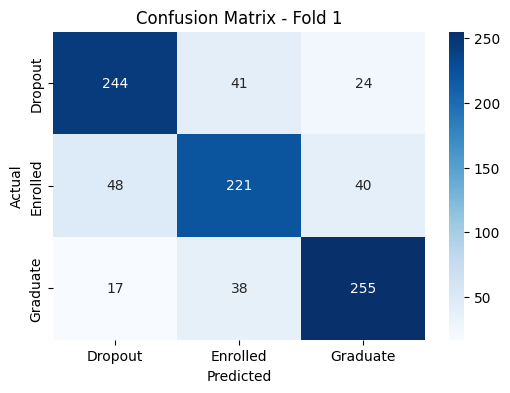


==================== FOLD 2 ====================
Accuracy   : 0.7392
F1 Macro   : 0.7359


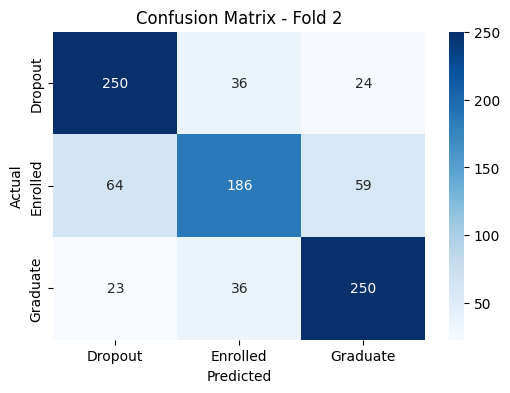


==================== FOLD 3 ====================
Accuracy   : 0.7565
F1 Macro   : 0.7549


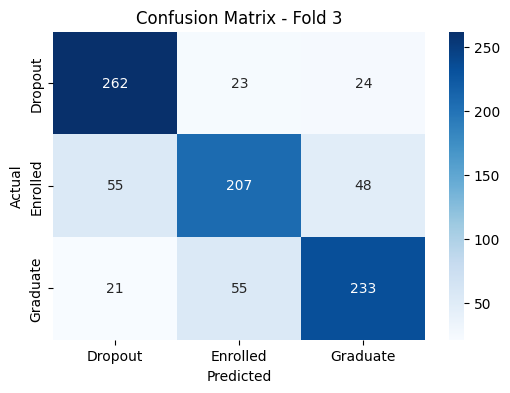


==================== FOLD 4 ====================
Accuracy   : 0.7530
F1 Macro   : 0.7508


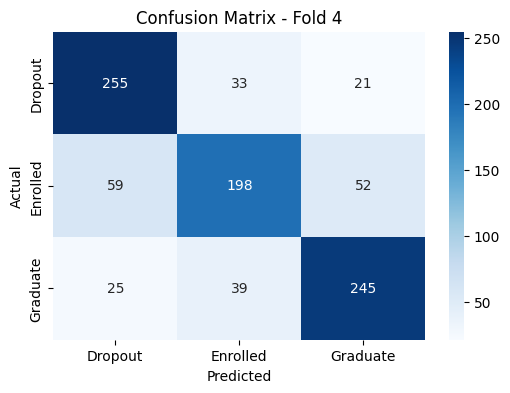


==================== FOLD 5 ====================
Accuracy   : 0.7551
F1 Macro   : 0.7538


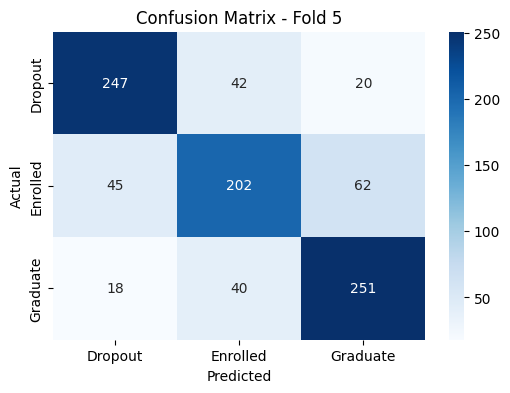


============= FINAL CROSS-VALIDATION RESULTS =============
Avg Accuracy   : 0.7559 ± 0.0117
Avg F1 Macro   : 0.7542
Avg F1 Weighted: 0.7542


In [14]:

X = df.drop(columns=["Target"])  
y = df["Target"]               

evaluate_custom_hierarchical(X, y, k=5, lr=0.1, n_iters=13000,penalty='elasticnet', C=0.15559818286283781) #0.7542


In [15]:
from matplotlib.animation import FuncAnimation, FFMpegWriter
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

def create_training_animation(X, y, lr=0.1, n_iters=100, penalty='l2', C=1.0,
                              filename='logreg_training.mp4', fps=10):
    """
    Create animated visualization of logistic regression training.
    Shows loss contours and parameter trajectory for 2D case (2 features).
    
    Parameters:
    -----------
    X : array-like, shape (n_samples, 2)
        Training features (must be 2D for visualization)
    y : array-like, shape (n_samples,)
        Binary labels (0 or 1)
    lr : float
        Learning rate
    n_iters : int
        Number of training iterations
    penalty : str
        Regularization type
    C : float
        Regularization strength
    filename : str
        Output filename for the MP4 video
    fps : int
        Frames per second for the animation
    """
    
    # Ensure we have 2 features for visualization
    X = np.asarray(X)
    y = np.asarray(y)
    
    if X.shape[1] != 2:
        print("WARNING: Visualisasi ini bekerja terbaik dengan 2 fitur.")
        print(f"Menggunakan 2 fitur pertama dari {X.shape[1]} fitur yang tersedia.")
        X = X[:, :2]
    
    # Train model and collect history
    print("Melatih model dan mengumpulkan histori parameter...")
    model = LogisticRegression(
        lr=lr, n_iters=n_iters, penalty=penalty, C=C, random_state=42
    )
    model.fit(X, y)
    
    # Extract parameter history
    weight_history = np.array(model.weight_history)
    bias_history = np.array(model.bias_history)
    loss_history = np.array(model.loss_history)
    
    print(f"Total frames yang akan dibuat: {len(loss_history)}")
    
    # Create loss surface grid
    print("Membuat permukaan loss...")
    theta0_range = np.linspace(
        weight_history[:, 0].min() - 1, 
        weight_history[:, 0].max() + 1, 50
    )
    theta1_range = np.linspace(
        weight_history[:, 1].min() - 1,
        weight_history[:, 1].max() + 1, 50
    )
    
    Theta0, Theta1 = np.meshgrid(theta0_range, theta1_range)
    Loss = np.zeros_like(Theta0)
    
    # Compute loss for each point in the grid
    for i in range(Theta0.shape[0]):
        for j in range(Theta0.shape[1]):
            w = np.array([Theta0[i, j], Theta1[i, j]])
            b = bias_history[0]  # Use initial bias
            
            linear = np.dot(X, w) + b
            predictions = 1 / (1 + np.exp(-np.clip(linear, -500, 500)))
            predictions = np.clip(predictions, 1e-10, 1 - 1e-10)
            
            loss = -np.mean(y * np.log(predictions) + (1 - y) * np.log(1 - predictions))
            
            # Add regularization
            if penalty == 'l2':
                loss += (1.0 / (2.0 * C * len(y))) * np.sum(w ** 2)
            elif penalty == 'elasticnet':
                l1_ratio = 0.5
                loss += (1.0 / (2.0 * C * len(y))) * (l1_ratio * np.sum(np.abs(w)) + (1 - l1_ratio) * np.sum(w ** 2))
            
            Loss[i, j] = loss
    
    # Create animation
    print("Membuat animasi...")
    fig = plt.figure(figsize=(16, 5))
    
    # Plot 1: Loss contour with trajectory
    ax1 = fig.add_subplot(131)
    
    # Plot 2: 3D loss surface
    ax2 = fig.add_subplot(132, projection='3d')
    
    # Plot 3: Loss vs iteration
    ax3 = fig.add_subplot(133)
    
    def init():
        ax1.clear()
        ax2.clear()
        ax3.clear()
        return []
    
    def update(frame):
        ax1.clear()
        ax2.clear()
        ax3.clear()
        
        # --- Plot 1: Contour plot with trajectory ---
        contour = ax1.contour(Theta0, Theta1, Loss, levels=20, cmap='viridis', alpha=0.6)
        ax1.contourf(Theta0, Theta1, Loss, levels=20, cmap='viridis', alpha=0.3)
        ax1.clabel(contour, inline=True, fontsize=8)
        
        # Plot trajectory up to current frame
        if frame > 0:
            ax1.plot(weight_history[:frame, 0], weight_history[:frame, 1], 
                    'r-', linewidth=2, alpha=0.7, label='Lintasan Training')
            ax1.plot(weight_history[:frame, 0], weight_history[:frame, 1], 
                    'ro', markersize=3, alpha=0.5)
        
        # Plot current position
        ax1.plot(weight_history[frame, 0], weight_history[frame, 1], 
                'ro', markersize=10, label=f'Iterasi {frame}')
        
        # Plot starting and ending points
        ax1.plot(weight_history[0, 0], weight_history[0, 1], 
                'gs', markersize=12, label='Mulai')
        ax1.plot(weight_history[-1, 0], weight_history[-1, 1], 
                'b*', markersize=15, label='Akhir')
        
        ax1.set_xlabel('θ₀ (Weight 1)', fontsize=12)
        ax1.set_ylabel('θ₁ (Weight 2)', fontsize=12)
        ax1.set_title(f'Kontur Loss & Lintasan Parameter\nIterasi: {frame}/{len(loss_history)-1}', 
                     fontsize=13, fontweight='bold')
        ax1.legend(loc='best')
        ax1.grid(True, alpha=0.3)
        
        # --- Plot 2: 3D surface ---
        ax2.plot_surface(Theta0, Theta1, Loss, cmap='viridis', alpha=0.6, 
                        edgecolor='none')
        
        # Plot trajectory on 3D surface
        if frame > 0:
            trajectory_loss = [loss_history[i] for i in range(frame)]
            ax2.plot(weight_history[:frame, 0], weight_history[:frame, 1], 
                    trajectory_loss, 'r-', linewidth=2, label='Jalur')
        
        # Current position
        ax2.scatter(weight_history[frame, 0], weight_history[frame, 1], 
                   loss_history[frame], c='red', s=100, marker='o')
        
        ax2.set_xlabel('θ₀', fontsize=10)
        ax2.set_ylabel('θ₁', fontsize=10)
        ax2.set_zlabel('Loss', fontsize=10)
        ax2.set_title('Permukaan Loss 3D', fontsize=13, fontweight='bold')
        ax2.view_init(elev=25, azim=45)
        
        # --- Plot 3: Loss over iterations ---
        ax3.plot(range(frame + 1), loss_history[:frame + 1], 
                'b-', linewidth=2, label='Training Loss')
        ax3.plot(frame, loss_history[frame], 'ro', markersize=10)
        
        ax3.set_xlabel('Iterasi', fontsize=12)
        ax3.set_ylabel('Loss', fontsize=12)
        ax3.set_title('Loss vs Iterasi', fontsize=13, fontweight='bold')
        ax3.grid(True, alpha=0.3)
        ax3.legend()
        ax3.set_xlim(0, len(loss_history))
        ax3.set_ylim(min(loss_history) * 0.95, max(loss_history) * 1.05)
        
        # Add text info
        info_text = f'Loss: {loss_history[frame]:.4f}\n'
        info_text += f'θ₀: {weight_history[frame, 0]:.4f}\n'
        info_text += f'θ₁: {weight_history[frame, 1]:.4f}\n'
        info_text += f'bias: {bias_history[frame]:.4f}'
        ax3.text(0.02, 0.98, info_text, transform=ax3.transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        return []
    
    # Create animation - gunakan semua frame atau subsample jika terlalu banyak
    max_frames = min(200, len(loss_history))  # Max 200 frames untuk video yang smooth
    if len(loss_history) > max_frames:
        step = len(loss_history) // max_frames
        frames = list(range(0, len(loss_history), step))
    else:
        frames = list(range(len(loss_history)))
    
    # Always include the last frame
    if (len(loss_history) - 1) not in frames:
        frames.append(len(loss_history) - 1)
    
    print(f"Membuat video dengan {len(frames)} frames...")
    
    anim = FuncAnimation(fig, update, frames=frames, init_func=init, 
                        blit=False, repeat=True, interval=1000//fps)
    
    # Save animation as MP4
    print(f"Menyimpan animasi ke {filename}...")
    writer = FFMpegWriter(fps=fps, bitrate=1800, codec='libx264')
    anim.save(filename, writer=writer)
    
    print(f"✓ Animasi berhasil disimpan sebagai MP4!")
    print(f"  File: {filename}")
    print(f"  Total iterasi: {len(loss_history)}")
    print(f"  Total frames dalam video: {len(frames)}")
    print(f"  Durasi video: {len(frames)/fps:.1f} detik")
    print(f"  Final Loss: {loss_history[-1]:.4f}")
    print(f"  Final θ₀: {weight_history[-1, 0]:.4f}")
    print(f"  Final θ₁: {weight_history[-1, 1]:.4f}")
    print(f"  Final bias: {bias_history[-1]:.4f}")
    
    plt.close()
    
    return model, weight_history, bias_history, loss_history

# Generate synthetic data untuk visualisasi
from sklearn.datasets import make_classification

print("Generating dataset untuk visualisasi...")
X, y = make_classification(n_samples=200, n_features=2, n_informative=2,
                          n_redundant=0, n_clusters_per_class=1,
                          random_state=42)

# Create animation
print("\n" + "="*60)
print("MEMBUAT VIDEO ANIMASI TRAINING LOGISTIC REGRESSION")
print("="*60)
model, weights, biases, losses = create_training_animation(
    X, y,
    lr=0.1,
    n_iters=1300,  # Dikurangi agar video tidak terlalu panjang
    penalty='elasticnet',
    C=0.15559818286283781,
    filename='logreg_training_kontur_loss.mp4',
    fps=15  # 15 fps untuk smooth video
)
print("\nVideo menampilkan:")
print("1. Garis kontur fungsi loss (log-loss)")
print("2. Lintasan parameter (θ₀, θ₁) selama training")
print("3. Permukaan loss 3D")
print("4. Grafik loss vs iterasi")
print("="*60)

Generating dataset untuk visualisasi...

MEMBUAT VIDEO ANIMASI TRAINING LOGISTIC REGRESSION
Melatih model dan mengumpulkan histori parameter...
Total frames yang akan dibuat: 1301
Membuat permukaan loss...
Membuat animasi...
Membuat video dengan 218 frames...
Menyimpan animasi ke logreg_training_kontur_loss.mp4...
✓ Animasi berhasil disimpan sebagai MP4!
  File: logreg_training_kontur_loss.mp4
  Total iterasi: 1301
  Total frames dalam video: 218
  Durasi video: 14.5 detik
  Final Loss: 0.3696
  Final θ₀: 1.6554
  Final θ₁: -0.3044
  Final bias: 0.1065

Video menampilkan:
1. Garis kontur fungsi loss (log-loss)
2. Lintasan parameter (θ₀, θ₁) selama training
3. Permukaan loss 3D
4. Grafik loss vs iterasi


In [ ]:
# def hyperparameter_tune(X_train, y_train, X_val=None, y_val=None, 
#                         cv=5, method='grid', n_iter=50, verbose=True, n_iters=1000, lr=0.01):
#     from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
#     from sklearn.metrics import accuracy_score, classification_report
    
#     param_grid = {
#         'penalty': ['l1', 'l2', 'elasticnet', 'none'],
#         'C': [0.11, 0.12, 0.15, 0.16, 0.17],
#         # 'C': np.logspace(-4, 4, 20),
#         'max_iter'  : [100,1000,2500,5000],
#         'lr' : [0.001,0.01,0.1, 0.2, 1.0]

#     }
    
#     base_model = MulticlassLogisticRegression(
#         lr=lr,
#         n_iters=n_iters,
#         class_weight='balanced'
#     )
    
#     if verbose:
#         print("="*60)
#         print("HYPERPARAMETER TUNING")
#         print("="*60)
#         print(f"Method: {method.upper()}")
#         print(f"Parameter grid:")
#         for key, val in param_grid.items():
#             if isinstance(val, np.ndarray):
#                 print(f"  {key}: [{val[0]:.4f} ... {val[-1]:.4f}] ({len(val)} values)")
#             else:
#                 print(f"  {key}: {val}")
#         print()
    
#     # Choose search method
#     if method == 'grid':
#         search = GridSearchCV(
#             base_model,
#             param_grid,
#             cv=cv,
#             scoring='accuracy',
#             n_jobs=-1,
#             verbose=2 if verbose else 0
#         )
#     elif method == 'random':
#         search = RandomizedSearchCV(
#             base_model,
#             param_grid,
#             n_iter=n_iter,
#             cv=cv,
#             scoring='accuracy',
#             n_jobs=-1,
#             verbose=2 if verbose else 0,
#             random_state=42
#         )
#     else:
#         raise ValueError("method must be 'grid' or 'random'")
    
#     # Fit the search
#     if verbose:
#         print("Starting hyperparameter search...")
#         print()
    
#     search.fit(X_train, y_train)
    
#     best_model = search.best_estimator_
    
#     if X_val is not None and y_val is not None:
#         y_pred = best_model.predict(X_val)
#         val_accuracy = accuracy_score(y_val, y_pred)
#     else:
#         val_accuracy = None
    
#     results = {
#         'best_params': search.best_params_,
#         'best_cv_score': search.best_score_,
#         'val_accuracy': val_accuracy,
#         'cv_results': search.cv_results_
#     }
    
#     if verbose:
#         print("\n" + "="*60)
#         print("RESULTS")
#         print("="*60)
#         print(f"Best CV Score: {search.best_score_:.4f}")
#         print(f"\nBest Parameters:")
#         for key, val in search.best_params_.items():
#             print(f"  {key}: {val}")
        
#         if val_accuracy is not None:
#             print(f"\nValidation Accuracy: {val_accuracy:.4f}")
#             print("\nClassification Report (Validation Set):")
#             print(classification_report(y_val, y_pred))
        
#         print("\nTop 5 Parameter Combinations:")
#         cv_results_df = pd.DataFrame(search.cv_results_)
#         top_5 = cv_results_df.nsmallest(5, 'rank_test_score')[
#             ['rank_test_score', 'mean_test_score', 'param_penalty', 'param_C']
#         ]
#         print(top_5.to_string(index=False))
#         print("="*60)
    
#     return best_model, results


# if __name__ == "__main__":
#     from sklearn.datasets import make_classification
#     from sklearn.model_selection import train_test_split
    
#     print("Generating synthetic dataset...")
#     X, y = make_classification(
#         n_samples=13000,
#         n_features=20,
#         n_informative=15,
#         n_redundant=5,
#         n_classes=3,
#         random_state=67
#     )
    
#     X_train, X_test, y_train, y_test = train_test_split(
#         X, y, test_size=0.2, random_state=67
#     )
    
#     print("\n" + "METHOD 1: Grid Search CV")
#     best_model_grid, results_grid = hyperparameter_tune(
#         X_train, y_train,
#         cv=5,
#         method='grid',
#         verbose=True
#     )
    
#     y_pred = best_model_grid.predict(X_test)
#     test_accuracy = accuracy_score(y_test, y_pred)
#     print(f"\nFinal Test Accuracy: {test_accuracy:.4f}")
    
#     print("\n" + "="*80)
    
#     print("\METHOD 2: Random Search CV (50 iterations)")
#     best_model_random, results_random = hyperparameter_tune(
#         X_train, y_train,
#         cv=5,
#         method='random',
#         n_iter=50,
#         verbose=True
#     )
    
#     y_pred = best_model_random.predict(X_test)
#     test_accuracy = accuracy_score(y_test, y_pred)
#     print(f"\nFinal Test Accuracy: {test_accuracy:.4f}")
    
#     print("\n" + "="*80)
    
#     # Method 3: With separate validation set
#     print("\n🎯 METHOD 3: Grid Search with Hold-out Validation")
#     X_tr, X_val, y_tr, y_val = train_test_split(
#         X_train, y_train, test_size=0.2, random_state=42
#     )
    
#     best_model_holdout, results_holdout = hyperparameter_tune(
#         X_tr, y_tr,
#         X_val=X_val,
#         y_val=y_val,
#         method='random',
#         n_iter=100,
#         verbose=True
#     )
    
#     y_pred = best_model_holdout.predict(X_test)
#     test_accuracy = accuracy_score(y_test, y_pred)
#     print(f"\nFinal Test Accuracy: {test_accuracy:.4f}")


## E. Submission
To predict the test set target feature and submit the results to the kaggle competition platform, do the following:
1. Create a new pipeline instance identical to the first in Data Preprocessing
2. With the pipeline, apply `fit_transform` to the original training set before splitting, then only apply `transform` to the test set.
3. Retrain the model on the preprocessed training set
4. Predict the test set
5. Make sure the submission contains the `id` and `attack_cat` column.

In [ ]:
import pandas as pd
import numpy as np
import os
import datetime

def create_hierarchical_submission(df, test_df, 
                                 logreg_params=None, 
                                 submission_folder='../submission'):

    if logreg_params is None:
        logreg_params = {
            'lr': 0.1, 
            'n_iters': 13000, 
            'class_weight': 'balanced', 
            'C': 1.0, 
            'penalty': 'l2', 
            'random_state': 67
        }
    
    os.makedirs(submission_folder, exist_ok=True)
    
    print("="*60)
    print("CREATING HIERARCHICAL SUBMISSION")
    print("Strategy: Stage 1 (Dropout vs Rest) -> Stage 2 (Graduate vs Enrolled)")
    
    if "Student_ID" in df.columns:
        df_train_clean = df.drop(columns=["Student_ID"])
    else:
        df_train_clean = df.copy()
    
    y = df_train_clean["Target"]
    X = df_train_clean.drop(columns=["Target"])
    
    test_ids = test_df["Student_ID"]
    if "Student_ID" in test_df.columns:
        X_test = test_df.drop(columns=["Student_ID"])
    else:
        X_test = test_df.copy()
        
    X_test = X_test[X.columns]
    
    print("Scaling features...")
    X_mean = X.mean()
    X_std = X.std()
    
    X_std = X_std.replace(0, 1)
    
    X_scaled = (X - X_mean) / X_std
    X_test_scaled = (X_test - X_mean) / X_std
    X_scaled_np = X_scaled.values
    X_test_scaled_np = X_test_scaled.values

    print("\n[Stage 1] Training Dropout Detector...")
    
    y_stage1 = (y == 'Dropout').astype(int)
    
    model_stage1 = MulticlassLogisticRegression(**logreg_params)
    model_stage1.fit(X_scaled_np, y_stage1)
    y_pred_stage1 = model_stage1.predict(X_test_scaled_np)
    
    print("[Stage 2] Training Status Classifier (Grad vs Enrolled)...")
    
    mask_non_dropout = (y != 'Dropout')
    X_stage2 = X_scaled_np[mask_non_dropout]
    y_stage2 = y[mask_non_dropout]
    
    model_stage2 = MulticlassLogisticRegression(**logreg_params)
    model_stage2.fit(X_stage2, y_stage2)
    
    y_pred_stage2 = model_stage2.predict(X_test_scaled_np)
    print("Combining predictions...")
    final_predictions = []
    
    for i in range(len(X_test)):
        
        if y_pred_stage1[i] == 1:
            final_predictions.append("Dropout")
        else:
            final_predictions.append(y_pred_stage2[i])
            
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = os.path.join(submission_folder, f"submission_hierarchical_{timestamp}.csv")
    
    submission = pd.DataFrame({
        "Student_ID": test_ids,
        "Target": final_predictions
    })
    
    submission.to_csv(filename, index=False)
    
    print(f"\nSubmission saved as {filename}")
    print(f"Total predictions: {len(final_predictions)}")
    print(f"Class distribution: {submission['Target'].value_counts().to_dict()}")
    
    return submission, (model_stage1, model_stage2)

submission, models = create_hierarchical_submission(
    df, 
    df_test,
    logreg_params={
        'lr': 0.1, 
        'n_iters': 13000, 
        'class_weight': 'balanced',
        'C': 0.1559818286283781, 
        'penalty': 'elasticnet', 
        'random_state': 67
    },
    submission_folder='../submission'
)

CREATING HIERARCHICAL SUBMISSION
Strategy: Stage 1 (Dropout vs Rest) -> Stage 2 (Graduate vs Enrolled)
Scaling features...

[Stage 1] Training Dropout Detector...


KeyboardInterrupt: 


FOLD 1
Training sklearn LogisticRegression...
Accuracy   : 0.7769
F1 Macro   : 0.7776
F1 Weighted: 0.7776
Accuracy   : 0.7769
F1 Macro   : 0.7776
F1 Weighted: 0.7776


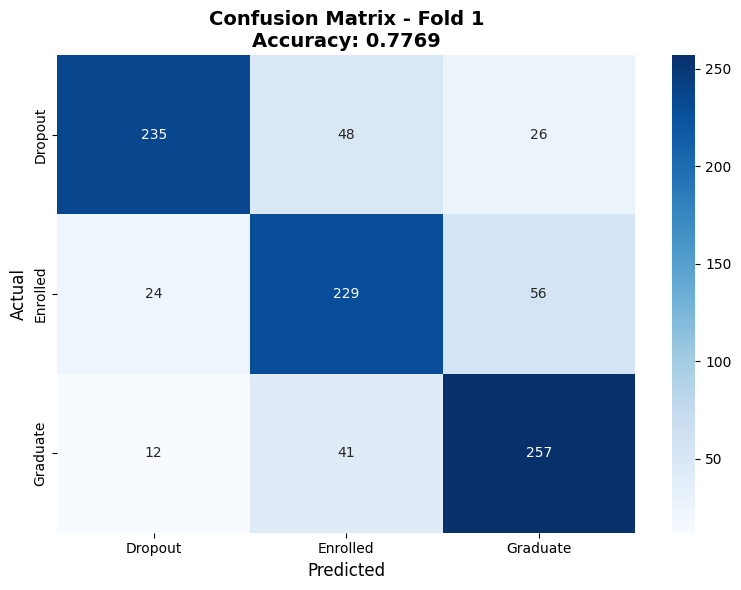


FOLD 2
Training sklearn LogisticRegression...
Accuracy   : 0.7457
F1 Macro   : 0.7450
F1 Weighted: 0.7450
Accuracy   : 0.7457
F1 Macro   : 0.7450
F1 Weighted: 0.7450


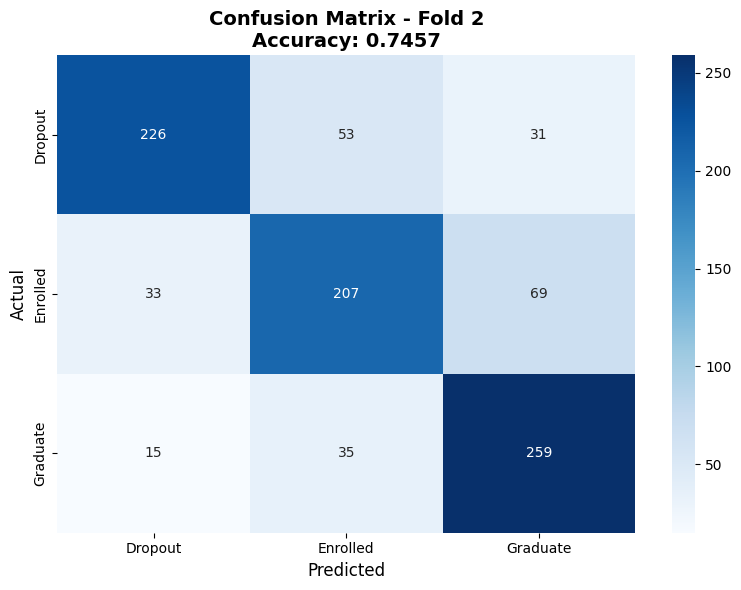


FOLD 3
Training sklearn LogisticRegression...
Accuracy   : 0.7381
F1 Macro   : 0.7382
F1 Weighted: 0.7382
Accuracy   : 0.7381
F1 Macro   : 0.7382
F1 Weighted: 0.7382


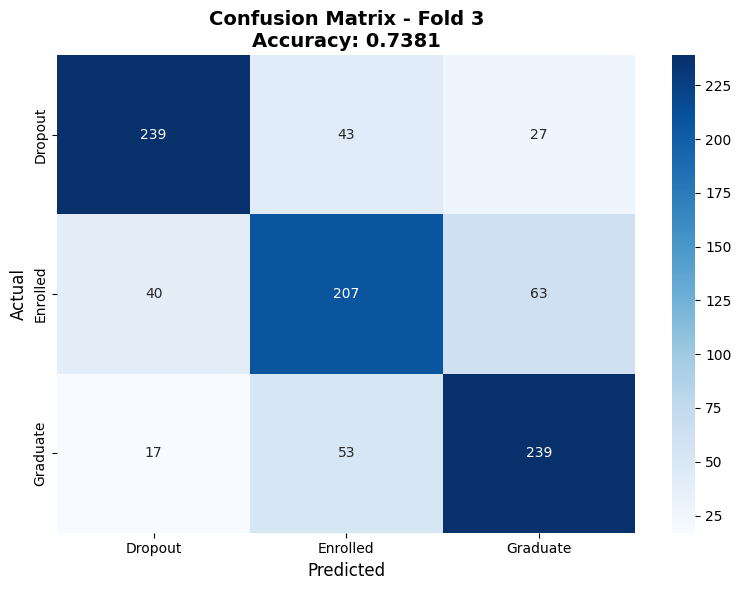


FOLD 4
Training sklearn LogisticRegression...
Accuracy   : 0.7368
F1 Macro   : 0.7352
F1 Weighted: 0.7352
Accuracy   : 0.7368
F1 Macro   : 0.7352
F1 Weighted: 0.7352


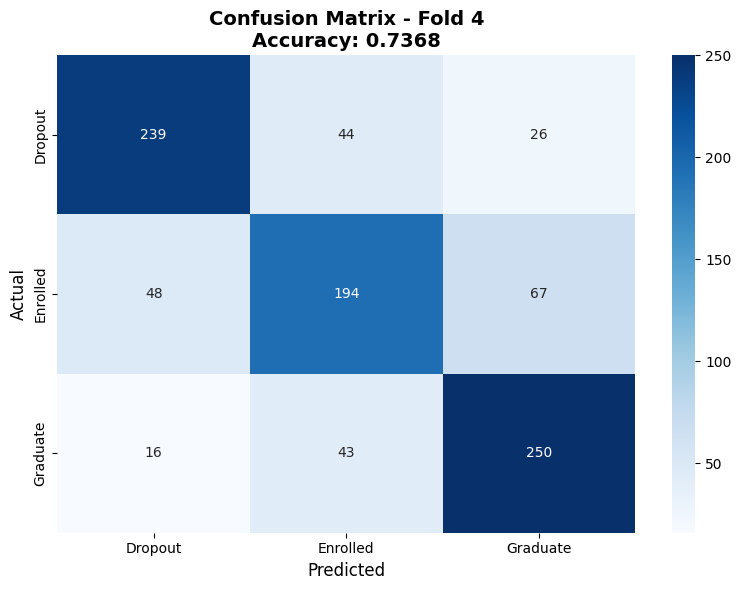


FOLD 5
Training sklearn LogisticRegression...
Accuracy   : 0.7497
F1 Macro   : 0.7496
F1 Weighted: 0.7496
Accuracy   : 0.7497
F1 Macro   : 0.7496
F1 Weighted: 0.7496


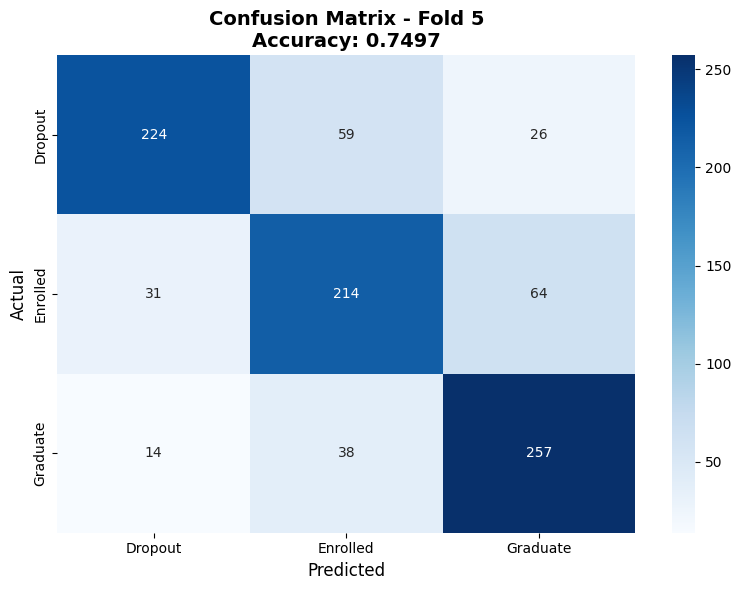


FINAL CROSS-VALIDATION RESULTS
Avg Accuracy   : 0.7495 ± 0.0145
Avg F1 Macro   : 0.7491 ± 0.0151
Avg F1 Weighted: 0.7491 ± 0.0151


In [ ]:
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_sklearn_logreg(X, y, k=5, logreg_params=None):
    """
    Evaluate sklearn's LogisticRegression using StratifiedKFold cross-validation
    with confusion matrix visualization for each fold.
    """
    if logreg_params is None:
        logreg_params = {
            'penalty': 'elasticnet',
            'C': 0.15559818286283781,
            'solver': 'saga',
            'max_iter': 13000,
            'l1_ratio': 0.5,
            'class_weight': 'balanced',
            'multi_class': 'ovr',
            'random_state': 67
        }
    
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=67)
    
    accuracies = []
    f1_macro_scores = []
    f1_weighted_scores = []
    
    fold = 1
    for train_idx, val_idx in skf.split(X, y):
        print(f"\n{'='*60}")
        print(f"FOLD {fold}")
        print(f"{'='*60}")
        
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        X_mean = X_train.mean()
        X_std = X_train.std().replace(0, 1)
        
        X_train_scaled = (X_train - X_mean) / X_std
        X_val_scaled = (X_val - X_mean) / X_std
        
        print("Training sklearn LogisticRegression...")
        model = SklearnLogisticRegression(**logreg_params)
        model.fit(X_train_scaled, y_train)
        
        y_pred = model.predict(X_val_scaled)
        
        acc = accuracy_score(y_val, y_pred)
        f1_macro = f1_score(y_val, y_pred, average='macro')
        f1_weighted = f1_score(y_val, y_pred, average='weighted')
        
        accuracies.append(acc)
        f1_macro_scores.append(f1_macro)
        f1_weighted_scores.append(f1_weighted)
        
        print(f"Accuracy   : {acc:.4f}")
        print(f"F1 Macro   : {f1_macro:.4f}")
        print(f"F1 Weighted: {f1_weighted:.4f}")
        
        cm = confusion_matrix(y_val, y_pred, labels=['Dropout', 'Enrolled', 'Graduate'])
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=["Dropout", "Enrolled", "Graduate"],
                    yticklabels=["Dropout", "Enrolled", "Graduate"])
        plt.xlabel("Predicted", fontsize=12)
        plt.ylabel("Actual", fontsize=12)
        plt.title(f"Confusion Matrix - Fold {fold}\nAccuracy: {acc:.4f}", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        fold += 1
    
    print("\n" + "="*60)
    print("FINAL CROSS-VALIDATION RESULTS")
    print("="*60)
    print(f"Avg Accuracy   : {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
    print(f"Avg F1 Macro   : {np.mean(f1_macro_scores):.4f} ± {np.std(f1_macro_scores):.4f}")
    print(f"Avg F1 Weighted: {np.mean(f1_weighted_scores):.4f} ± {np.std(f1_weighted_scores):.4f}")
    print("="*60)
    
    return {
        'accuracies': accuracies,
        'f1_macro_scores': f1_macro_scores,
        'f1_weighted_scores': f1_weighted_scores,
        'mean_accuracy': np.mean(accuracies),
        'std_accuracy': np.std(accuracies),
        'mean_f1_macro': np.mean(f1_macro_scores),
        'mean_f1_weighted': np.mean(f1_weighted_scores)
    }

# Evaluate model
X = df.drop(columns=["Target"])  
y = df["Target"]

results = evaluate_sklearn_logreg(
    X, y, 
    k=5,
    logreg_params={
        'penalty': 'elasticnet',
        'C': 0.15559818286283781,
        'solver': 'saga',
        'max_iter': 13000,
        'l1_ratio': 0.5,
        'class_weight': 'balanced',
        'multi_class': 'ovr',
        'random_state': 67
    }
)

# 6. Error Analysis

Based on all the process you have done until the modeling and evaluation step, write an analysis to support each steps you have taken to solve this problem. Write the analysis using the markdown block. Some questions that may help you in writing the analysis:

- Does my model perform better in predicting one class than the other? If so, why is that?
- To each models I have tried, which performs the best and what could be the reason?
- Is it better for me to impute or drop the missing data? Why?
- Does feature scaling help improve my model performance?
- etc...

`Provide your analysis here`